# 03 — Baseline Model

LightGBM regresyon modeli ile `harvest_twso` tahmini.

**Giriş:** `data/processed/train.parquet` + `test.parquet`  
**Hedef:** RMSE ve R² benchmark oluştur

In [8]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import root_mean_squared_error, r2_score
from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

PROCESSED = Path('../data/processed')
FIGS = '../outputs/figures/'

## 1. Veriyi yükle

In [9]:
train = pd.read_parquet(PROCESSED / 'train.parquet')
test  = pd.read_parquet(PROCESSED / 'test.parquet')

TARGET = 'harvest_twso'
FEATURES = [c for c in train.columns if c != TARGET]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print('Features:', FEATURES)

Train: (34013, 14) | Test: (7410, 14)
Features: ['mean_temp', 'total_precip', 'mean_humidity', 'mean_rftra', 'max_lai', 'max_tagp', 'max_dvs', 'season_days', 'latitude', 'longitude', 'elevation', 'year', 'WAV', 'crop_te']


## 2. Model eğit

In [10]:
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
)

print(f'En iyi iterasyon: {model.best_iteration_}')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000252 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1916
[LightGBM] [Info] Number of data points in the train set: 34013, number of used features: 14
[LightGBM] [Info] Start training from score 2049.027386
[100]	valid_0's l2: 377279
[200]	valid_0's l2: 336220
[300]	valid_0's l2: 322535
[400]	valid_0's l2: 317894
[500]	valid_0's l2: 313545
[600]	valid_0's l2: 311001
[700]	valid_0's l2: 308457
[800]	valid_0's l2: 307429
[900]	valid_0's l2: 306273
En iyi iterasyon: 937


## 3. Değerlendirme

In [11]:
y_pred = model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
mae  = np.mean(np.abs(y_test - y_pred))

print(f'RMSE : {rmse:,.1f} kg/ha')
print(f'MAE  : {mae:,.1f} kg/ha')
print(f'R²   : {r2:.4f}')

RMSE : 553.3 kg/ha
MAE  : 292.8 kg/ha
R²   : 0.9637


## 4. Tahmin vs Gerçek

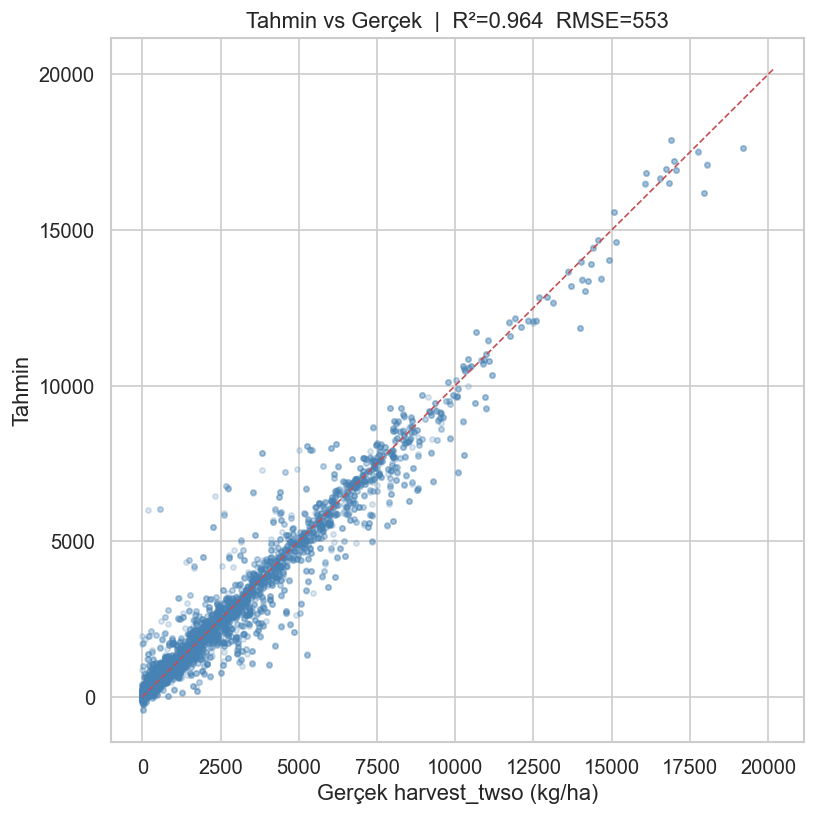

In [12]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, y_pred, alpha=0.2, s=10, color='steelblue')
lim = max(y_test.max(), y_pred.max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', lw=1)
ax.set_xlabel('Gerçek harvest_twso (kg/ha)')
ax.set_ylabel('Tahmin')
ax.set_title(f'Tahmin vs Gerçek  |  R²={r2:.3f}  RMSE={rmse:,.0f}')
plt.tight_layout()
plt.savefig(FIGS + 'pred_vs_actual.png', bbox_inches='tight')
plt.show()

## 5. Feature Importance

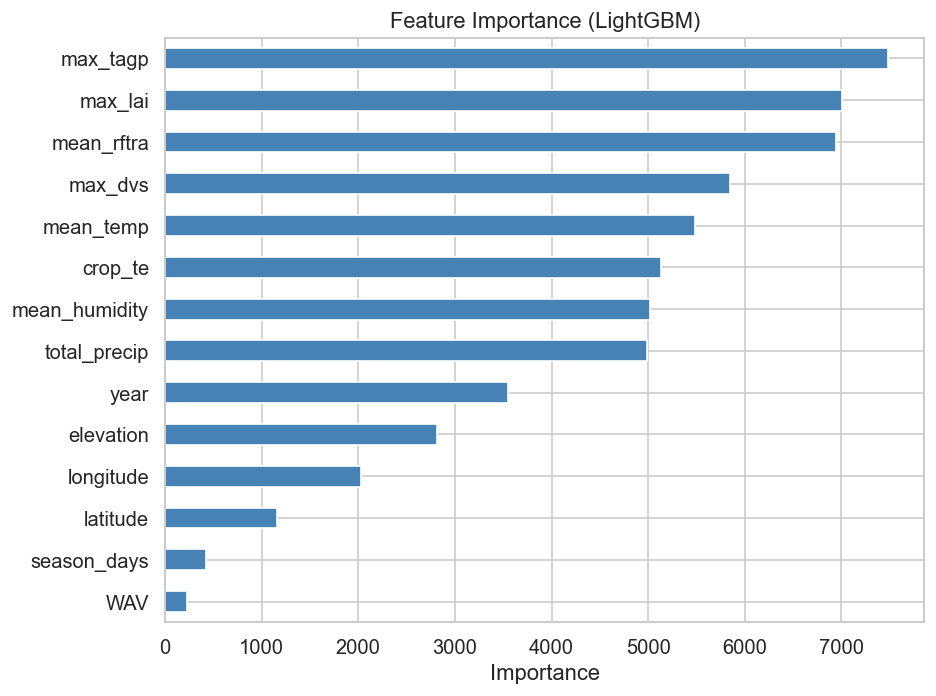

In [13]:
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Feature Importance (LightGBM)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(FIGS + 'feature_importance.png', bbox_inches='tight')
plt.show()

## 6. Bitki bazında hata analizi

In [14]:
results = test.copy()
results['y_pred'] = y_pred
results['abs_error'] = np.abs(y_test.values - y_pred)

crop_err = (results.groupby('crop_te')
            .agg(rmse=('abs_error', lambda x: np.sqrt((x**2).mean())),
                 n=('abs_error', 'count'))
            .sort_values('rmse'))

print(crop_err.to_string())

                    rmse    n
crop_te                      
1092.451290   156.004839  405
64.385510     159.987766   99
613.178161    164.303611  388
219.231781    170.980005  311
687.346287    175.773190  333
515.834191    183.220526  311
11.335393     190.608580   18
555.421382    196.391661  275
4798.587416   214.755391  417
521.271023    249.576413  343
443.593454    262.689294  364
1098.829701   263.252247  378
2201.424793   279.683643  402
4479.661070   333.144043  417
5425.534632   414.679510  417
2115.445476   416.819568  360
1171.326110   424.173351  388
2204.834833   484.918020  414
1908.833900   569.803897  362
1489.253652   813.687532  345
4047.227872  1220.986366  336
4813.100935  1646.818295  327


## 7. Çıktıları kaydet

In [15]:
import json
from pathlib import Path

OUTPUTS = Path("../outputs")
OUTPUTS.mkdir(exist_ok=True)

# Metrikler
metrics = {"rmse": round(rmse, 2), "mae": round(mae, 2), "r2": round(r2, 4),
           "best_iteration": int(model.best_iteration_),
           "n_train": len(train), "n_test": len(test)}
with open(OUTPUTS / "baseline_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

# Tahminler
results[["crop_te", "latitude", "longitude", "year", "harvest_twso", "y_pred", "abs_error"]].to_parquet(
    OUTPUTS / "baseline_predictions.parquet", index=False)

# Feature importance
imp.sort_values(ascending=False).to_csv(OUTPUTS / "feature_importance.csv", header=["importance"])

print("Kaydedildi:")
for p in sorted(OUTPUTS.glob("baseline*")) + sorted(OUTPUTS.glob("feature*")):
    print(" ", p)


Kaydedildi:
  ../outputs/baseline_metrics.json
  ../outputs/baseline_predictions.parquet
  ../outputs/feature_importance.csv


In [16]:
import joblib

MODELS_DIR = OUTPUTS / "models"
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(model, MODELS_DIR / "baseline_lgbm_fullseason.joblib")
print(f"Kaydedildi: {MODELS_DIR}/baseline_lgbm_fullseason.joblib")


Kaydedildi: ../outputs/models/baseline_lgbm_fullseason.joblib
